In [1]:
from notebook_env import *
from sklearn.neighbors import KNeighborsClassifier

In [2]:
def build_group(alpha, beta, is_positive):
    pos = scipy.stats.uniform(loc=1)
    neg = scipy.stats.uniform(loc=-2)
    if is_positive:
        return evoml.RandomVariablePopulationGroup(
            rv_vec=[
                evoml.MixtureRandomVariable(
                    rv_vec=[
                        neg,
                        pos,
                    ],
                    p=[
                        (1-beta)/(1-beta+beta*alpha),
                        (beta*alpha)/(1-beta+beta*alpha),
                    ],
                ),
                pos,
            ],
            p = [
                1-beta*(1-alpha),
                beta*(1-alpha),
            ]
        )
    else:
        return evoml.RandomVariablePopulationGroup(
            rv_vec=[
                neg,
                evoml.MixtureRandomVariable(
                    rv_vec=[
                        pos,
                        neg,
                    ],
                    p=[
                        (1-beta)/(1-beta+beta*alpha),
                        (beta*alpha)/(1-beta+beta*alpha),
                    ],
                ),
            ],
            p = [
                beta*(1-alpha),
                1-beta*(1-alpha),
            ]
        )

alpha=0.2
beta=0.8


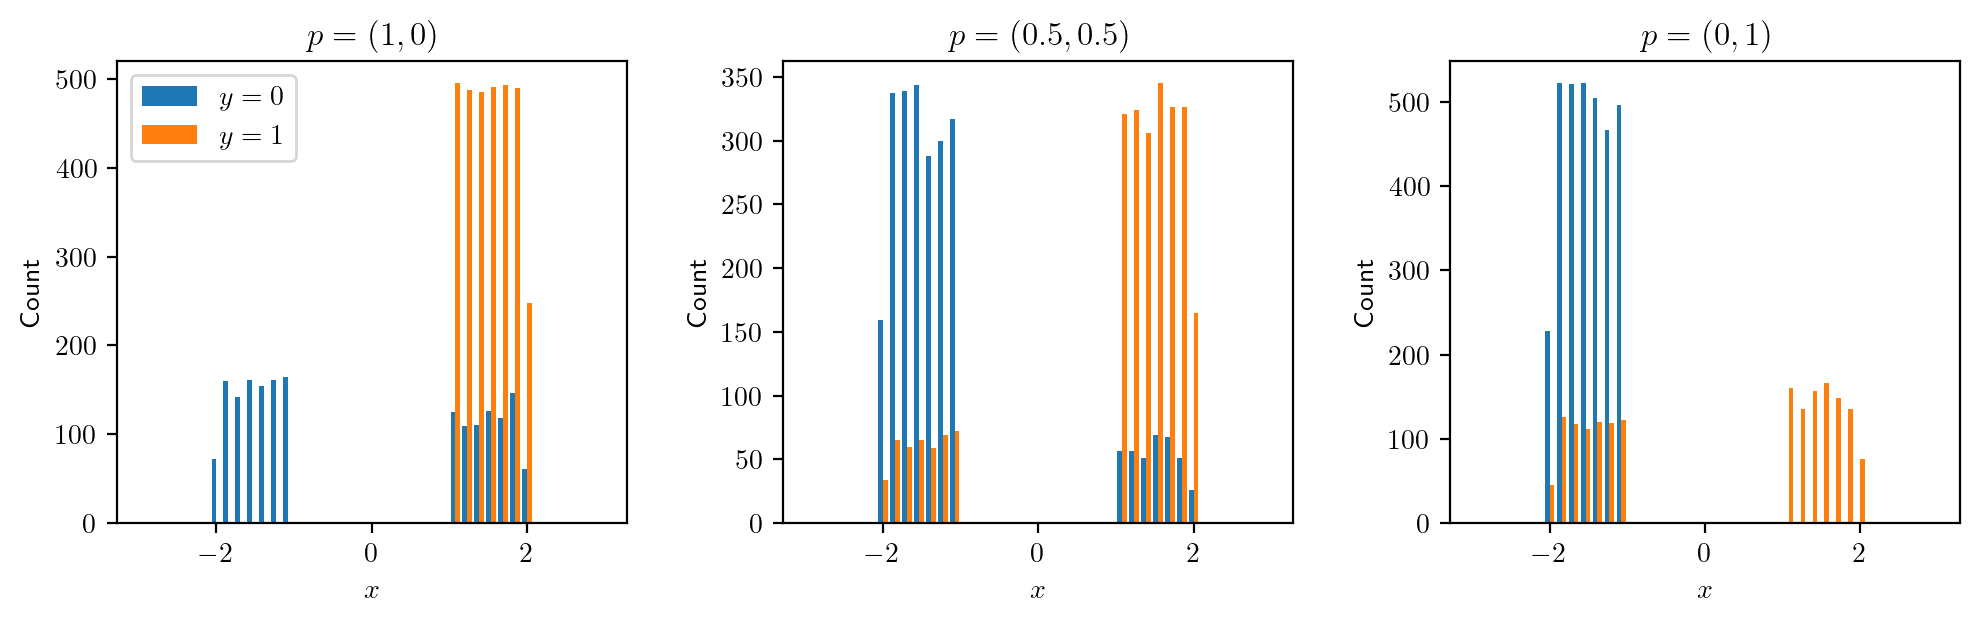

In [3]:
alpha = param(0.2,'alpha')
beta = param(0.8,'beta')
pop = evoml.Population(groups=[
    build_group(alpha=alpha, beta=beta, is_positive=is_pos) for is_pos in [True, False]
])

fig,axs=evoml.create_figure(1,3)
for p,ax in zip([0,0.5,1],axs):
    X,y,_ = pop.sample_from_mixture(5000, p=[1-p,p])
    ax.hist(
        [X[y==0].ravel(), X[y==1].ravel()],
        bins=np.linspace(-3,3,40),
    )
    ax.set(
        title=f'$p=({1-p},{p})$',
        xlabel='$x$',
        ylabel='Count',
    )

axs[0].legend([
    '$y=0$',
    '$y=1$',
])


In [4]:
k_vec = [1,3,5]
n_reps = 20

n_train = 10000
n_test = 10000

results = []
p_vec = np.linspace(0,1,7)
for rep in tqdm(range(n_reps)):
    for k in k_vec:
        clf = KNeighborsClassifier(n_neighbors=k)
        for p in p_vec:
            clf.fit(*pop.sample_from_mixture(n=n_train,p=[1-p,p])[:2])
            results.append({
                'k': k,
                'p': p,
                'rep': rep,
                'acc_A': clf.score(*pop.sample_from_group(n=n_test,g=0)),
                'acc_B': clf.score(*pop.sample_from_group(n=n_test,g=1)),
            })

  0%|          | 0/20 [00:00<?, ?it/s]

In [5]:
results_df = pd.DataFrame(results)
results_df.head()

,k,p,rep,acc_A,acc_B
0,1,0.000000,0,0.7428,0.7959
1,1,0.166667,0,0.7440,0.7583
2,1,0.333333,0,0.7207,0.7373
3,1,0.500000,0,0.7301,0.7307
4,1,0.666667,0,0.7476,0.7274


Figure saved as ./output/knn_theoretical_curves.pdf


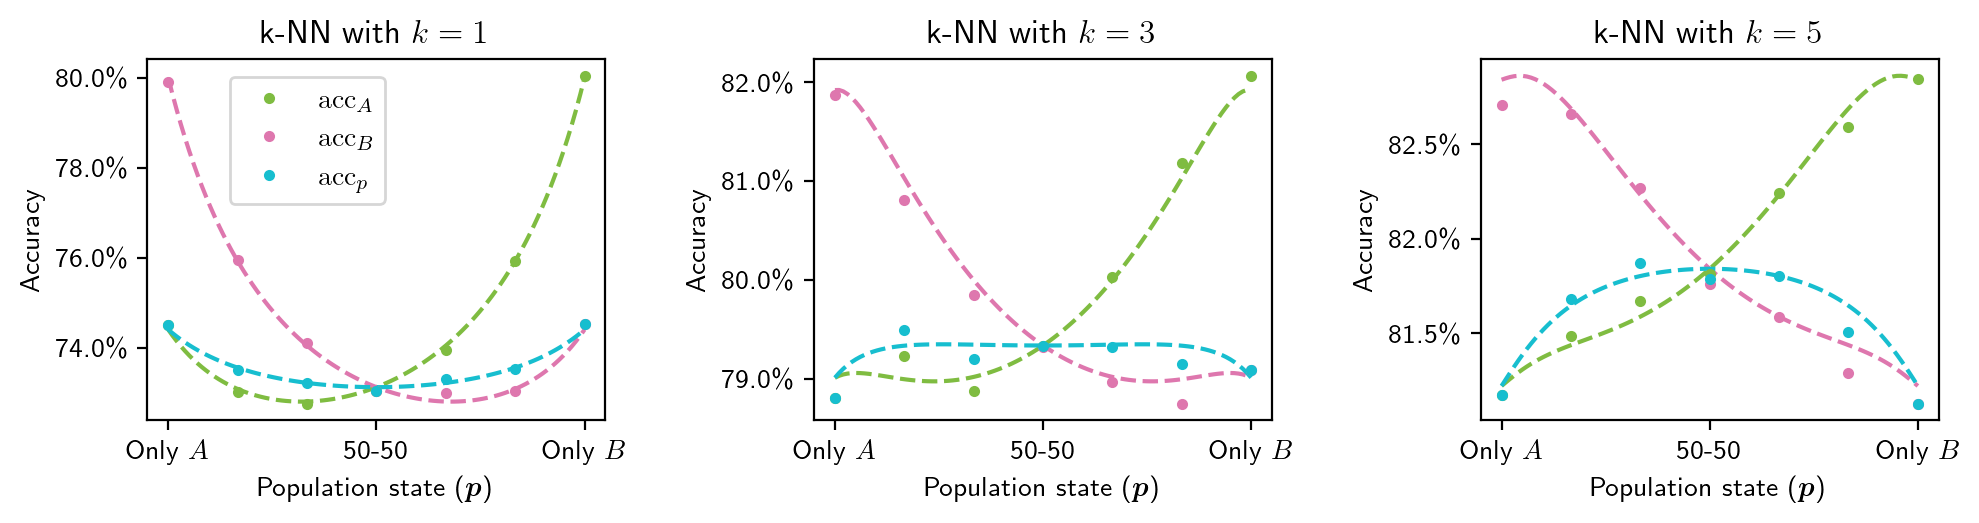

In [6]:
fig,axs=evoml.create_figure(
    1,3,
    figsize=(10,2.5)
)

for k,ax in zip(k_vec,axs):
    (
        results_df
        .query('k==@k')
        .assign(acc_p=lambda df: (1-df['p'])*df['acc_A'] + df['p']*df['acc_B'])
        .groupby('p')
        .mean()
        .pipe(lambda df: df[[c for c in df.columns if c.startswith('acc')]])
        .plot.line(
            ax=ax,
            marker='.',
            linestyle='',
            title=f'k-NN with $k={k}$',
            legend=False,
            xlabel='$p_B$',
            ylabel='Accuracy',
            color=[
                evoml.group_colors[0],
                evoml.group_colors[1],
                'tab:cyan',
            ]
        )
    )
    ax.set(
        xlabel=evoml.analysis.composition_label,
        xticks=evoml.analysis.composition_tickpos[::-1],
        xticklabels=evoml.analysis.composition_ticklabels,
    )
    ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1,decimals=1))
    ## Theory
    p = np.linspace(0,1,100)
    binom_cdf = lambda p: scipy.stats.binom.cdf(n=k,k=k//2,p=p)
    gamma = p - 2*p*beta + beta
    noise_coeff_pos = beta*(1-p)/gamma
    noise_coeff_neg = beta*p/(1-gamma)
    # exp_yhat_pos = 1-2*binom_cdf(1-noise_coeff_pos*alpha)
    # exp_yhat_neg = -1+2*binom_cdf(1-noise_coeff_neg*alpha)
    exp_yhat_pos = -1+2*binom_cdf(noise_coeff_pos*alpha)
    exp_yhat_neg = 1-2*binom_cdf(noise_coeff_neg*alpha)
    acc_pos = (1+(1-2*alpha)*exp_yhat_pos)/2
    acc_neg = (1+(-1)*exp_yhat_neg)/2
    acc_A = beta*acc_pos + (1-beta)*acc_neg
    acc_B = acc_A[::-1]
    line_params = {
        'linestyle': '--',
        'zorder': -1,
    }
    ax.plot(p, acc_A, label='acc_A',color=evoml.group_colors[0], **line_params)
    ax.plot(p, acc_B, label='acc_B',color=evoml.group_colors[1], **line_params)
    ax.plot(p, (1-p)*acc_A+p*acc_B, color='tab:cyan', **line_params)

axs[0].legend(
    [
        '$\\mathrm{acc}_A$',
        '$\\mathrm{acc}_B$',
        '$\\mathrm{acc}_p$',
    ],
    loc=(0.18,0.60),
)

fig.save_and_download('./output/knn_theoretical_curves.pdf')

In [7]:
param_tracker.save('./output/knn.json')

Parameters saved as: ./output/knn.json
